In [2]:

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import os
import time

# Set seeds
torch.manual_seed(42)
np.random.seed(42)




In [3]:


# Load splits
train_data = pd.read_pickle('dataset/train_data_final.pkl')
val_data_masked = pd.read_pickle('dataset/val_data_masked.pkl')
test_data_masked = pd.read_pickle('dataset/test_data_masked.pkl')

# Load ground truth and masks
val_ground_truth = pd.read_pickle('dataset/val_ground_truth.pkl')
test_ground_truth = pd.read_pickle('dataset/test_ground_truth.pkl')
val_mask_indicator = pd.read_pickle('dataset/val_mask_indices.pkl')
test_mask_indicator = pd.read_pickle('dataset/test_mask_indices.pkl')

print(f"\n Loaded splits:")
print(f"   Train: {train_data.shape}")
print(f"   Val: {val_data_masked.shape}")
print(f"   Test: {test_data_masked.shape}")

# Get features to impute (from ground truth columns)
features_to_impute = val_ground_truth.columns.tolist()

print(f"   Features to impute: {len(features_to_impute)}")


 Loaded splits:
   Train: (143459, 96)
   Val: (30741, 96)
   Test: (30742, 96)
   Features to impute: 35


In [ ]:
def clip_outliers_per_feature(data, features, lower_pct=0.5, upper_pct=99.5, 
                               reference_data=None):
    """
    Clip outliers per feature based on percentiles.
    """
    data_clipped = data.copy()
    clipping_bounds = {}
    
    for feat in features:
        if feat not in data.columns:
            continue
        
        # Determine which data to use for percentiles
        if reference_data is not None:
            ref_col = reference_data[feat].dropna()
        else:
            ref_col = data[feat].dropna()
        
        if len(ref_col) == 0:
            continue
        
        # Calculate bounds
        lower_bound = np.percentile(ref_col, lower_pct)
        upper_bound = np.percentile(ref_col, upper_pct)
        
        clipping_bounds[feat] = (lower_bound, upper_bound)
        
        # Clip values (only non-NaN)
        mask = data_clipped[feat].notna()
        data_clipped.loc[mask, feat] = data_clipped.loc[mask, feat].clip(
            lower=lower_bound, 
            upper=upper_bound
        )
    
    return data_clipped, clipping_bounds

print("\n Clipping training data (fit bounds)...")
train_clipped, clipping_bounds = clip_outliers_per_feature(
    train_data, 
    features_to_impute
)

print(" Training data clipped")

# Show some clipping examples
print(f"\n Clipping examples (first 5 features):")
for i, feat in enumerate(list(clipping_bounds.keys())[:5]):
    lower, upper = clipping_bounds[feat]
    original_min = train_data[feat].min()
    original_max = train_data[feat].max()
    print(f"   {feat[:40]:40s}: [{original_min:>10.2e}, {original_max:>10.2e}] → [{lower:>10.2e}, {upper:>10.2e}]")

# Clip val and test using SAME bounds (from training)
print("\n Clipping val/test data (using training bounds)...")
val_clipped, _ = clip_outliers_per_feature(
    val_data_masked, 
    features_to_impute,
    reference_data=train_data
)

test_clipped, _ = clip_outliers_per_feature(
    test_data_masked, 
    features_to_impute,
    reference_data=train_data
)

print(" Val/test data clipped")

# CRITICAL: Also clip ground truth
print("\n Clipping ground truth (same bounds)...")
val_gt_clipped, _ = clip_outliers_per_feature(
    val_ground_truth,
    features_to_impute,
    reference_data=train_data
)

test_gt_clipped, _ = clip_outliers_per_feature(
    test_ground_truth,
    features_to_impute,
    reference_data=train_data
)

print(" Ground truth clipped")


 Clipping training data (fit bounds)...
 Training data clipped

 Clipping examples (first 5 features):
   ping_ms                                 : [  2.83e+00,   1.14e+01] → [  3.04e+00,   8.65e+00]
   datarate                                : [  6.75e+00,   1.93e+01] → [  1.29e+01,   1.88e+01]
   jitter                                  : [  1.60e-05,   1.01e+08] → [  4.70e-05,   3.86e-02]
   Latitude                                : [  5.25e+01,   5.25e+01] → [  5.25e+01,   5.25e+01]
   Longitude                               : [  1.32e+01,   1.34e+01] → [  1.33e+01,   1.34e+01]

 Clipping val/test data (using training bounds)...
 Val/test data clipped

 Clipping ground truth (same bounds)...
 Ground truth clipped


In [6]:

scaler = StandardScaler()

# Extract values for features to impute
train_values = train_clipped[features_to_impute].values
val_values = val_clipped[features_to_impute].values
test_values = test_clipped[features_to_impute].values

# Fit scaler on training data
scaler.fit(train_values)

# Transform all datasets
train_scaled = scaler.transform(train_values)
val_scaled = scaler.transform(val_values)
test_scaled = scaler.transform(test_values)

print(f"\n Scaled all datasets")

# Verify scale quality
print(f"\nScaled data statistics:")
print(f"   Train mean: {np.nanmean(train_scaled):.4f}")
print(f"   Train std:  {np.nanstd(train_scaled):.4f}")
print(f"   Train min:  {np.nanmin(train_scaled):.4f}")
print(f"   Train max:  {np.nanmax(train_scaled):.4f}")


 Scaled all datasets

Scaled data statistics:
   Train mean: 0.0000
   Train std:  1.0000
   Train min:  -3.9694
   Train max:  8.8233


In [7]:
# Get ALL column names
all_columns = train_data.columns.tolist()

# Separate features
continuous_features = features_to_impute  # 49 features (what we impute)


context_features = [col for col in all_columns if col not in continuous_features]




In [8]:
exclude_patterns = [
    'pcell_high_missing',
    'timestamp',
    'ts_gps','date'                                                                                 
]


In [9]:
context_features = [col for col in context_features 
                    if col not in exclude_patterns]

In [11]:


print(f"\n Feature breakdown:")
print(f"   Continuous (to impute): {len(continuous_features)}")
print(f"   Context (indicators, temporal, one-hot): {len(context_features)}")
print(f"   Total input features: {len(all_columns)}")

print(f"\n Context features:")
for col in context_features:
    print(f"   {col}")



 Feature breakdown:
   Continuous (to impute): 35
   Context (indicators, temporal, one-hot): 59
   Total input features: 96

 Context features:
   operator
   device_pc1
   device_pc2
   device_pc3
   direction_uplink
   measured_qos_delay
   hour
   day_of_week
   ping_ms_missing
   datarate_missing
   jitter_missing
   Latitude_missing
   Longitude_missing
   Altitude_missing
   speed_kmh_missing
   COG_missing
   precipIntensity_missing
   precipProbability_missing
   temperature_missing
   humidity_missing
   windSpeed_missing
   Traffic Jam Factor_missing
   Traffic Distance_missing
   Pos in Ref Round_missing
   measurement_missing
   PCell_RSRP_max_missing
   PCell_RSRQ_max_missing
   PCell_RSSI_max_missing
   PCell_SNR_1_missing
   PCell_SNR_2_missing
   PCell_Downlink_Num_RBs_missing
   PCell_Downlink_TB_Size_missing
   PCell_Downlink_Average_MCS_missing
   PCell_Uplink_Num_RBs_missing
   PCell_Uplink_TB_Size_missing
   PCell_Uplink_Tx_Power_(dBm)_missing
   PCell_Downlink_f

In [12]:
train_data

,timestamp,ping_ms,datarate,jitter,Latitude,Longitude,Altitude,speed_kmh,COG,precipIntensity,...,PCell_Downlink_frequency_3050.0,PCell_Downlink_frequency_3749.0,PCell_Downlink_frequency_9460.0,PCell_freq_MHz_700.0,PCell_freq_MHz_900.0,PCell_freq_MHz_1800.0,PCell_freq_MHz_2000.0,PCell_freq_MHz_2100.0,PCell_freq_MHz_2600.0,date
0,2021-06-22 09:49:54+02:00,NaN,18.045260,0.000848,52.514013,13.335172,41.9,0.000000,0.0,0.0652,...,0,0,0,0,0,1,0,0,0,2021-06-22
1,2021-06-22 09:49:54+02:00,NaN,17.014184,0.000512,52.514008,13.335195,35.3,0.000000,259.0,0.0652,...,0,0,0,0,0,1,0,0,0,2021-06-22
2,2021-06-22 09:49:54+02:00,NaN,17.723526,0.000090,52.513830,13.334935,30.7,0.000000,0.0,0.0653,...,0,0,0,0,0,0,0,0,1,2021-06-22
3,2021-06-22 09:49:54+02:00,7.242082,18.071123,0.000207,52.513848,13.334832,32.3,0.000000,265.9,0.0653,...,0,0,0,0,0,1,0,0,0,2021-06-22
4,2021-06-22 09:49:55+02:00,NaN,16.850464,0.002268,52.514005,13.335195,35.4,0.000000,259.0,0.0652,...,0,0,0,0,0,1,0,0,0,2021-06-22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143454,2021-06-23 15:51:36+02:00,3.254243,12.884109,0.002815,52.513112,13.329863,35.9,0.000000,84.0,0.0646,...,0,0,0,0,0,0,1,0,0,2021-06-23
143455,2021-06-23 15:51:36+02:00,3.781914,12.884109,0.002089,52.513095,13.329760,34.5,0.000000,84.3,0.0646,...,0,0,0,0,0,1,0,0,0,2021-06-23
143456,2021-06-23 15:51:36+02:00,3.254243,12.884109,0.003071,52.513088,13.329952,32.5,0.000000,83.6,0.0646,...,0,0,0,0,0,0,0,0,1,2021-06-23
143457,2021-06-23 15:51:36+02:00,3.342155,12.906694,0.001906,52.513153,13.331378,28.6,2.463138,83.3,0.0646,...,0,0,0,0,0,1,0,0,0,2021-06-23


In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Get context features
train_context = train_data[context_features].values  # Fill any NaN with 0
val_context = val_data_masked[context_features].values
test_context = test_data_masked[context_features].values


# Scale context features
context_scaler = MinMaxScaler()

# Fit on train context
context_scaler.fit(train_context)

# Transform all
train_context_scaled = context_scaler.transform(train_context)
val_context_scaled = context_scaler.transform(val_context)
test_context_scaled = context_scaler.transform(test_context)




In [14]:


# Combine: [scaled continuous | raw context]
train_full = np.hstack([train_scaled,train_context])
val_full = np.hstack([val_scaled,val_context])
test_full = np.hstack([test_scaled,test_context])

print(f"\n Combined features:")
print(f"   Train: {train_full.shape}")
print(f"   Val: {val_full.shape}")
print(f"   Test: {test_full.shape}")

# Verify
print(f"\n Full input statistics:")
print(f"   Mean: {np.nanmean(train_full):.4f}")
print(f"   Std: {np.nanstd(train_full):.4f}")
print(f"   Min: {np.nanmin(train_full):.4f}")
print(f"   Max: {np.nanmax(train_full):.4f}")


 Combined features:
   Train: (143459, 94)
   Val: (30741, 94)
   Test: (30742, 94)

 Full input statistics:
   Mean: 0.2184
   Std: 1.5206
   Min: -3.9694
   Max: 18.0000


In [15]:


import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import time

# Seeds
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n Device: {device}")


 Device: cpu


In [16]:

print(f"\n Using existing preprocessed data:")
print(f"   Train: {train_full.shape}")
print(f"   Val: {val_full.shape}")
print(f"   Test: {test_full.shape}")


 Using existing preprocessed data:
   Train: (143459, 94)
   Val: (30741, 94)
   Test: (30742, 94)


In [ ]:
class SimpleDenoisingAutoencoder(Dataset):
    """Dataset with continuous and context features"""
    
    def __init__(self, full_data, continuous_data, context_data, noise_ratio=0.2, training=True):
        """
        Parameters:
            full_data: All features combined (numpy array)
            continuous_data: Continuous features (for input & target)
            context_data: Context features (binary/categorical)
            noise_ratio: Artificial noise for training
            training: Whether to add noise
        """
        self.continuous_data = continuous_data
        self.context_data = context_data
        self.noise_ratio = noise_ratio
        self.training = training
        self.n_continuous = continuous_data.shape[1]
        self.n_context = context_data.shape[1]
    
    def __len__(self):
        return len(self.continuous_data)
    
    def __getitem__(self, idx):
        continuous_row = self.continuous_data[idx].copy()
        context_row = self.context_data[idx].copy()
        
        # Mask for continuous features (1=observed, 0=missing)
        mask_observed = ~np.isnan(continuous_row)
        
        # Fill NaN in continuous with 0
        continuous_filled = np.nan_to_num(continuous_row, nan=0.0)
        
        # Fill NaN in context with 0
        context_filled = np.nan_to_num(context_row, nan=0.0)
        
        if self.training and mask_observed.sum() > 0:
            continuous_input = continuous_filled.copy()
            
            # Mask some observed continuous values
            observed_indices = np.where(mask_observed)[0]
            n_to_mask = max(1, int(len(observed_indices) * self.noise_ratio))
            if n_to_mask < len(observed_indices):
                mask_indices = np.random.choice(
                    observed_indices, size=n_to_mask, replace=False
                )
                continuous_input[mask_indices] = 0.0
            
            # Combine: [noisy continuous | clean context]
            full_input = np.concatenate([continuous_input, context_filled])
        else:
            # Validation/test: no noise
            full_input = np.concatenate([continuous_filled, context_filled])
        
        return (torch.FloatTensor(full_input),                        # Input: continuous + context
                torch.FloatTensor(continuous_filled),                  # Target: continuous only
                torch.FloatTensor(mask_observed.astype(np.float32)))   # Mask: continuous only


# Create datasets
NOISE_RATIO = 0.2
BATCH_SIZE = 512

train_dataset = SimpleDenoisingAutoencoder(train_full, train_scaled, train_context, noise_ratio=NOISE_RATIO, training=True)
val_dataset = SimpleDenoisingAutoencoder(val_full, val_scaled, val_context, noise_ratio=0.0, training=False)
test_dataset = SimpleDenoisingAutoencoder(test_full, test_scaled, test_context, noise_ratio=0.0, training=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\n Datasets created:")
print(f"   Train: {len(train_dataset):,} samples (20% noise)")
print(f"   Val: {len(val_dataset):,} samples")
print(f"   Test: {len(test_dataset):,} samples")
print(f"   Input features: {train_dataset.n_continuous} continuous + {train_dataset.n_context} context")
print(f"   Batch size: {BATCH_SIZE}")


 Datasets created:
   Train: 143,459 samples (20% noise)
   Val: 30,741 samples
   Test: 30,742 samples
   Input features: 35 continuous + 59 context
   Batch size: 512


In [ ]:

class SimpleDenoisingAutoencoder(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dims=[128, 64, 32]):
        super(SimpleDenoisingAutoencoder, self).__init__()
        
        # Encoder
        encoder_layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            encoder_layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(0.2)
            ])
            prev_dim = hidden_dim
        
        self.encoder = nn.Sequential(*encoder_layers)
        
        # Decoder
        decoder_layers = []
        reversed_dims = list(reversed(hidden_dims[:-1])) + [output_dim]
        
        for i, hidden_dim in enumerate(reversed_dims):
            decoder_layers.append(nn.Linear(prev_dim, hidden_dim))
            
            if i < len(reversed_dims) - 1:
                decoder_layers.extend([
                    nn.ReLU(),
                    nn.Dropout(0.2)
                ])
            
            prev_dim = hidden_dim
        
        self.decoder = nn.Sequential(*decoder_layers)
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

INPUT_DIM = 94
HIDDEN_DIMS = [128, 64, 32]
output_dim= 35

model = SimpleDenoisingAutoencoder(INPUT_DIM,output_dim, HIDDEN_DIMS).to(device)

print(f"\n Model created:")
print(f"   Architecture: {INPUT_DIM} → {' → '.join(map(str, HIDDEN_DIMS))} → {' → '.join(map(str, reversed(HIDDEN_DIMS[:-1])))} → {output_dim}")
print(f"   Parameters: {sum(p.numel() for p in model.parameters()):,}")


 Model created:
   Architecture: 94 → 128 → 64 → 32 → 64 → 128 → 35
   Parameters: 37,443


In [19]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

NUM_EPOCHS = 40
EARLY_STOP_PATIENCE = 10

print(f"\n  Configuration:")
print(f"   Epochs: {NUM_EPOCHS}")
print(f"   Learning rate: 0.001")
print(f"   Optimizer: Adam")
print(f"   Early stopping: {EARLY_STOP_PATIENCE}")


  Configuration:
   Epochs: 40
   Learning rate: 0.001
   Optimizer: Adam
   Early stopping: 10


In [20]:

history = {'train_loss': [], 'val_loss': [], 'epoch_times': []}
best_val_loss = float('inf')
patience_counter = 0
best_model_state = None

print(f"\n Starting training...")
print(f"{'Epoch':<8s} {'Train Loss':<15s} {'Val Loss':<15s} {'Time':<10s} {'Status'}")
print("─"*70)

for epoch in range(NUM_EPOCHS):
    epoch_start = time.time()
    
    # Training
    model.train()
    train_losses = []
    
    for input_batch, target_batch, mask_batch in train_loader:
        input_batch = input_batch.to(device)
        target_batch = target_batch.to(device)
        mask_batch = mask_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model(input_batch)
        
        # Loss only on observed values
        loss = criterion(outputs * mask_batch, target_batch * mask_batch)
        
        loss.backward()
        optimizer.step()
        
        train_losses.append(loss.item())
    
    avg_train_loss = np.mean(train_losses)
    
    # Validation
    model.eval()
    val_losses = []
    
    with torch.no_grad():
        for input_batch, target_batch, mask_batch in val_loader:
            input_batch = input_batch.to(device)
            target_batch = target_batch.to(device)
            mask_batch = mask_batch.to(device)
            
            outputs = model(input_batch)
            loss = criterion(outputs * mask_batch, target_batch * mask_batch)
            
            val_losses.append(loss.item())
    
    avg_val_loss = np.mean(val_losses)
    
    # Record
    epoch_time = time.time() - epoch_start
    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(avg_val_loss)
    history['epoch_times'].append(epoch_time)
    
    scheduler.step(avg_val_loss)
    
    # Early stopping
    status = ""
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_model_state = model.state_dict().copy()
        status = " Best!"
    else:
        patience_counter += 1
        status = f"({patience_counter}/{EARLY_STOP_PATIENCE})"
    
    print(f"{epoch+1:<8d} {avg_train_loss:<15.6f} {avg_val_loss:<15.6f} {epoch_time:<10.2f}s {status}")
    
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n  Early stopping at epoch {epoch+1}")
        break

# Restore best
model.load_state_dict(best_model_state)

print(f"\n Training complete!")
print(f"   Epochs: {len(history['train_loss'])}")
print(f"   Best val loss: {best_val_loss:.6f}")
print(f"   Total time: {sum(history['epoch_times']):.1f}s")



 Starting training...
Epoch    Train Loss      Val Loss        Time       Status
──────────────────────────────────────────────────────────────────────
1        0.560801        0.416192        17.09     s  Best!
2        0.388774        0.341027        19.05     s  Best!
3        0.349710        0.311222        19.19     s  Best!
4        0.326401        0.299824        19.66     s  Best!
5        0.310459        0.279729        20.43     s  Best!
6        0.299282        0.275466        19.17     s  Best!
7        0.291695        0.267247        18.53     s  Best!
8        0.285097        0.263425        20.68     s  Best!
9        0.279305        0.255367        30.64     s  Best!
10       0.274290        0.250009        34.09     s  Best!
11       0.269838        0.243899        19.00     s  Best!
12       0.265975        0.242213        18.90     s  Best!
13       0.263252        0.239483        18.77     s  Best!
14       0.261033        0.238295        18.98     s  Best!
15     

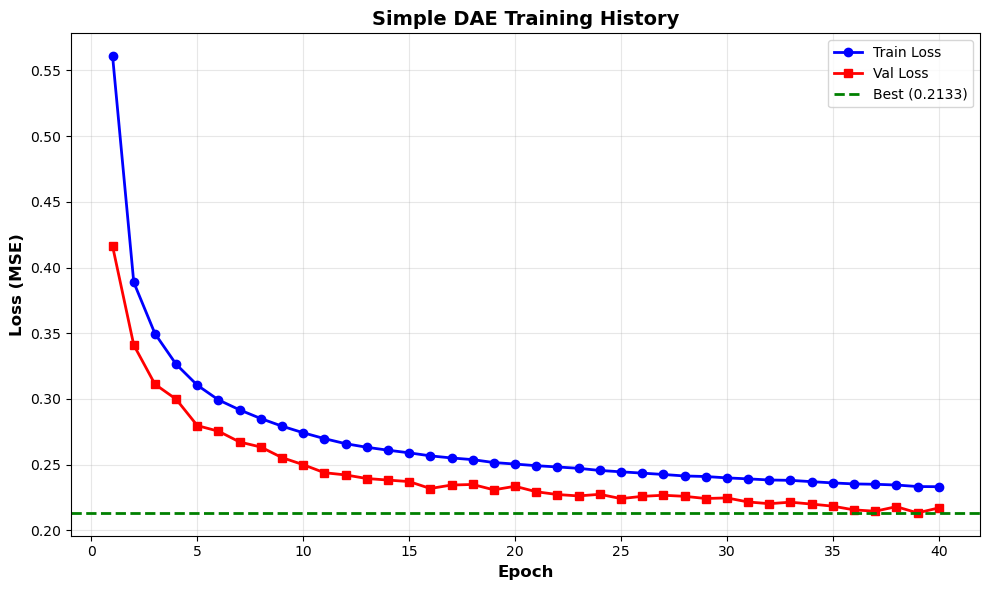

 SIMPLE DAE TRAINING COMPLETE

  RESULTS:
   Best validation loss: 0.213332
   Epochs: 40
   Total time: 849.4s

 NEXT: Evaluate on test set!



In [21]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

epochs = range(1, len(history['train_loss']) + 1)

ax.plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2, marker='o')
ax.plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2, marker='s')
ax.axhline(y=best_val_loss, color='g', linestyle='--', linewidth=2, label=f'Best ({best_val_loss:.4f})')
ax.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax.set_ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
ax.set_title('Simple DAE Training History', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()


print(" SIMPLE DAE TRAINING COMPLETE")


print(f"""
  RESULTS:
   Best validation loss: {best_val_loss:.6f}
   Epochs: {len(history['train_loss'])}
   Total time: {sum(history['epoch_times']):.1f}s

 NEXT: Evaluate on test set!
""")

In [22]:

from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

model.eval()
all_predictions = []

print("\n Generating predictions on test set...")

with torch.no_grad():
    for input_batch, _, _ in test_loader:
        input_batch = input_batch.to(device)
        outputs = model(input_batch)
        all_predictions.append(outputs.cpu().numpy())

predictions_scaled = np.vstack(all_predictions)

print(f" Predictions generated: {predictions_scaled.shape}")
print(f"   In scaled space (mean≈0, std≈1)")


 Generating predictions on test set...
 Predictions generated: (30742, 35)
   In scaled space (mean≈0, std≈1)


In [23]:

# Inverse transform predictions
predictions_original = scaler.inverse_transform(predictions_scaled)

print(f" Predictions transformed to original (clipped) scale")
print(f"   Shape: {predictions_original.shape}")
print(f"   Range: [{predictions_original.min():.2f}, {predictions_original.max():.2f}]")

# Create DataFrame with predictions
test_imputed = test_data_masked.copy()
test_imputed[continuous_features] = predictions_original

print(f" Created imputed test dataframe")

 Predictions transformed to original (clipped) scale
   Shape: (30742, 35)
   Range: [-119.35, 307.73]
 Created imputed test dataframe


In [24]:

results = []
all_errors_sq = []
all_errors_abs = []

for col in continuous_features:
    # Get mask: which positions were artificially masked?
    mask = test_mask_indicator[col]
    
    if mask.sum() == 0:
        continue  # No masked values for this feature
    
    # Get ground truth at masked positions (CLIPPED!)
    true_vals = test_gt_clipped.loc[mask, col].dropna()
    
    if len(true_vals) == 0:
        continue
    
    # Get predictions at same positions
    pred_vals = test_imputed.loc[true_vals.index, col]
    
    # Calculate errors
    errors = true_vals - pred_vals
    errors_sq = errors ** 2
    errors_abs = errors.abs()
    
    rmse = np.sqrt(errors_sq.mean())
    mae = errors_abs.mean()
    
    # Store results
    results.append({
        'feature': col,
        'n_masked': len(true_vals),
        'RMSE': rmse,
        'MAE': mae
    })
    
    # Collect for overall metrics
    all_errors_sq.extend(errors_sq.values)
    all_errors_abs.extend(errors_abs.values)

# Calculate overall metrics
overall_rmse = np.sqrt(np.mean(all_errors_sq))
overall_mae = np.mean(all_errors_abs)

print(f"\n OVERALL PERFORMANCE:")
print(f"   Overall RMSE: {overall_rmse:.4f}")
print(f"   Overall MAE:  {overall_mae:.4f}")
print(f"   Features evaluated: {len(results)}")
print(f"   Total evaluation points: {len(all_errors_sq):,}")


 OVERALL PERFORMANCE:
   Overall RMSE: 10.7091
   Overall MAE:  2.9895
   Features evaluated: 35
   Total evaluation points: 158,362


In [25]:
results_df = pd.DataFrame(results)
results_sorted = results_df.sort_values('RMSE')

print(f"\n TOP BEST FEATURES (Lowest RMSE):")
print(f"{'Feature':<50s} {'N Masked':>10s} {'RMSE':>12s} {'MAE':>12s}")
print("─"*90)
for idx, row in results_sorted.iterrows():
    print(f"{row['feature']:<50s} {row['n_masked']:>10.0f} {row['RMSE']:>12.4f} {row['MAE']:>12.4f}")




 TOP BEST FEATURES (Lowest RMSE):
Feature                                              N Masked         RMSE          MAE
──────────────────────────────────────────────────────────────────────────────────────────
jitter                                                   4555       0.0030       0.0014
Latitude                                                 4611       0.0046       0.0032
Longitude                                                4611       0.0185       0.0143
humidity                                                 4611       0.0581       0.0464
precipProbability                                        4611       0.0685       0.0616
precipIntensity                                          4611       0.1053       0.0978
PCell_Downlink_bandwidth_MHz                             4411       0.1872       0.1340
PCell_Uplink_bandwidth_MHz                               4411       0.1912       0.1368
PCell_Band_Indicator                                     4411       0.4724       0

In [26]:


import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_predictions = []

with torch.no_grad():
    for input_batch, _, _ in test_loader:
        input_batch = input_batch.to(device)
        outputs = model(input_batch)
        all_predictions.append(outputs.cpu().numpy())

predictions_scaled = np.vstack(all_predictions)
predictions_original = scaler.inverse_transform(predictions_scaled)

test_imputed = test_data_masked.copy()
test_imputed[continuous_features] = predictions_original

print(f" Predictions generated: {predictions_original.shape}")

 Predictions generated: (30742, 35)


In [27]:

results = []
all_errors = []
all_errors_abs = []

for col in continuous_features:
    mask = test_mask_indicator[col]
    
    if mask.sum() == 0:
        continue
    
    # Get ground truth (CLIPPED)
    true_vals = test_gt_clipped.loc[mask, col].dropna()
    
    if len(true_vals) == 0:
        continue
    
    pred_vals = test_imputed.loc[true_vals.index, col]
    
    # Calculate errors
    errors = true_vals - pred_vals
    errors_abs = errors.abs()
    errors_sq = errors ** 2
    
    # Basic metrics
    rmse = np.sqrt(errors_sq.mean())
    mae = errors_abs.mean()
    median_ae = errors_abs.median()
    
    # Normalized metrics (by range)
    feature_range = train_data[col].max() - train_data[col].min()
    nrmse = rmse / (feature_range + 1e-8)
    
    # Normalized metrics (by std)
    feature_std = train_data[col].std()
    nrmse_std = rmse / (feature_std + 1e-8)
    
    # Error distribution
    percentile_25 = errors_abs.quantile(0.25)
    percentile_75 = errors_abs.quantile(0.75)
    percentile_95 = errors_abs.quantile(0.95)
    
    # Store results
    results.append({
        'feature': col,
        'n_masked': len(true_vals),
        'RMSE': rmse,
        'MAE': mae,
        'MedianAE': median_ae,
        'NRMSE': nrmse,
        'NRMSE_std': nrmse_std,
        'feature_range': feature_range,
        'feature_std': feature_std,
        'error_p25': percentile_25,
        'error_p75': percentile_75,
        'error_p95': percentile_95
    })
    
    # Collect for overall metrics
    all_errors.extend(errors.values)
    all_errors_abs.extend(errors_abs.values)

results_df = pd.DataFrame(results)

In [28]:

# Calculate overall metrics
overall_rmse = np.sqrt(np.mean([e**2 for e in all_errors]))
overall_mae = np.mean(all_errors_abs)
overall_median_ae = np.median(all_errors_abs)
overall_nrmse = results_df['NRMSE'].mean()
overall_nrmse_std = results_df['NRMSE_std'].mean()

print(f"\n OVERALL METRICS:")
print(f"   RMSE:          {overall_rmse:,.2f}")
print(f"   MAE:           {overall_mae:,.2f}")
print(f"   Median AE:     {overall_median_ae:,.2f} ")
print(f"   NRMSE (range): {overall_nrmse:.4f} ")
print(f"   NRMSE (std):   {overall_nrmse_std:.4f}")
print(f"   Features:      {len(results)}")
print(f"   Eval points:   {len(all_errors):,}")

# Interpretation
print(f"\n INTERPRETATION:")
if overall_nrmse < 0.1:
    print(f"   EXCELLENT: NRMSE < 0.1 (errors < 10% of feature range)")
elif overall_nrmse < 0.3:
    print(f"   GOOD: NRMSE 0.1-0.3 (errors 10-30% of feature range)")
elif overall_nrmse < 0.5:
    print(f"    MODERATE: NRMSE 0.3-0.5 (errors 30-50% of feature range)")
else:
    print(f"   POOR: NRMSE > 0.5 (errors > 50% of feature range)")



 OVERALL METRICS:
   RMSE:          10.71
   MAE:           2.99
   Median AE:     0.64 
   NRMSE (range): 0.1987 
   NRMSE (std):   0.8573
   Features:      35
   Eval points:   158,362

 INTERPRETATION:
   GOOD: NRMSE 0.1-0.3 (errors 10-30% of feature range)


In [33]:
import os
os.makedirs('research/models', exist_ok=True)

torch.save({
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
    'clipping_bounds': clipping_bounds,
    'history': history,
    'hyperparameters': {
        'input_dim': INPUT_DIM,
        'hidden_dims': HIDDEN_DIMS,
        'batch_size': BATCH_SIZE,
        'noise_ratio': NOISE_RATIO,
        'best_val_loss': best_val_loss
    },
    'features': continuous_features
}, 'research/models/simple_dae_model_all_feat.pt')

print(" Saved: models/simple_dae_model_all_feat.pt")

# Save history
history_df = pd.DataFrame({
    'epoch': range(1, len(history['train_loss']) + 1),
    'train_loss': history['train_loss'],
    'val_loss': history['val_loss'],
    'epoch_time': history['epoch_times']
})
history_df.to_csv('research/models/simple_dae_history_all_feat.csv', index=False)
print(" Saved: models/simple_dae_history_all_feat.csv")


 Saved: models/simple_dae_model_all_feat.pt
 Saved: models/simple_dae_history_all_feat.csv
